### 1. Import Library
Materi ini mencakup berbagai teknik penanganan **imbalanced dataset** — kondisi di mana distribusi kelas sangat tidak merata (misalnya 90% kelas 0, 10% kelas 1). Kondisi ini sangat umum di dataset NLP/ML dunia nyata (fraud detection, spam, rare disease, dll.) dan jika tidak ditangani, model cenderung bias ke kelas mayoritas dan gagal mendeteksi kelas minoritas.

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from collections import Counter

# Untuk teknik resampling
from sklearn.utils import resample
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (classification_report, confusion_matrix,
                              roc_auc_score, f1_score, precision_score,
                              recall_score, accuracy_score, ConfusionMatrixDisplay)

# Untuk SMOTE dan varian oversampling lanjutan
try:
    from imblearn.over_sampling import SMOTE, ADASYN, BorderlineSMOTE
    from imblearn.under_sampling import RandomUnderSampler, TomekLinks, EditedNearestNeighbours
    from imblearn.combine import SMOTETomek, SMOTEENN
    from imblearn.pipeline import Pipeline as ImbPipeline
    IMBLEARN_AVAILABLE = True
    print("imbalanced-learn tersedia.")
except ImportError:
    IMBLEARN_AVAILABLE = False
    print("imbalanced-learn TIDAK tersedia. Install: pip install imbalanced-learn")
    print("Teknik berbasis sklearn.utils.resample tetap bisa digunakan.")

np.random.seed(42)
pd.set_option('display.max_columns', 20)
print(f"\nPandas  : {pd.__version__}")
print(f"NumPy   : {np.__version__}")

imbalanced-learn TIDAK tersedia. Install: pip install imbalanced-learn
Teknik berbasis sklearn.utils.resample tetap bisa digunakan.

Pandas  : 2.3.3
NumPy   : 2.2.6


### 2. Load Dataset dan Inspeksi Awal
Dataset yang digunakan adalah **Titanic** (`titanic_down.csv`) — sudah melalui preprocessing awal. Target kelas adalah kolom `Survived` (0 = tidak selamat, 1 = selamat). Dataset Titanic secara alami memiliki **ketidakseimbangan kelas** karena lebih banyak penumpang yang tidak selamat, menjadikannya contoh yang baik untuk belajar teknik imbalanced handling.

In [9]:
df = pd.read_csv('titanic_down.csv', index_col=0)

print(f"Shape: {df.shape}")
print(f"Kolom: {df.columns.tolist()}")
display(df.head())
display(df.dtypes)
display(df.isna().sum())

Shape: (680, 12)
Kolom: ['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Embarked', 'Short_Name']


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,Short_Name
0,313,0,2,"Lahtinen, Mrs. William (Anna Sylfven)",0,26.0,1,1,250651,26.0000,0.0,"lahtinen, mrs."
1,125,0,1,"White, Mr. Percival Wayland",1,54.0,0,1,35281,77.2875,0.0,"white, mr."
2,784,0,3,"Johnston, Mr. Andrew G",1,28.0,1,2,W./C. 6607,23.4500,0.0,"johnston, mr."
3,168,0,3,"Skoog, Mrs. William (Anna Bernhardina Karlsson)",0,45.0,1,4,347088,27.9000,0.0,"skoog, mrs."
4,773,0,2,"Mack, Mrs. (Mary)",0,57.0,0,0,S.O./P.P. 3,10.5000,0.0,"mack, mrs."


PassengerId      int64
Survived         int64
Pclass           int64
Name            object
Sex              int64
Age            float64
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
Embarked       float64
Short_Name      object
dtype: object

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
Short_Name     0
dtype: int64

### 3. Analisis Distribusi Kelas (Mengukur Imbalance)
Sebelum memilih teknik penanganan, wajib mengukur **seberapa parah** ketidakseimbangan. Metrik yang digunakan: rasio antar kelas dan **Imbalance Ratio (IR)** = jumlah kelas mayoritas / jumlah kelas minoritas. IR > 1.5 biasanya sudah perlu ditangani; IR > 10 tergolong ekstrem.

=== Distribusi Kelas ===
  Kelas 0 (Not Survived   ):   340 sampel (50.00%)
  Kelas 1 (Survived       ):   340 sampel (50.00%)

Imbalance Ratio (IR): 1.00
Selisih absolut     : 0 sampel
→ Status: SEIMBANG


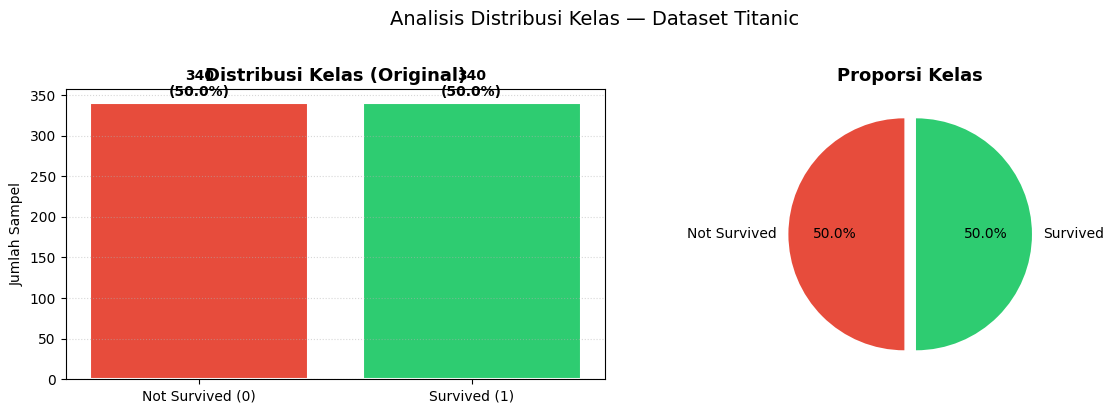

In [10]:
TARGET = 'Survived'

class_counts = df[TARGET].value_counts().sort_index()
class_pct    = df[TARGET].value_counts(normalize=True).sort_index() * 100

print("=== Distribusi Kelas ===")
for cls in class_counts.index:
    label = 'Survived' if cls == 1 else 'Not Survived'
    print(f"  Kelas {cls} ({label:15s}): {class_counts[cls]:5d} sampel ({class_pct[cls]:.2f}%)")

majority_count = class_counts.max()
minority_count = class_counts.min()
imbalance_ratio = majority_count / minority_count

print(f"\nImbalance Ratio (IR): {imbalance_ratio:.2f}")
print(f"Selisih absolut     : {majority_count - minority_count} sampel")

if imbalance_ratio < 1.5:
    print("→ Status: SEIMBANG")
elif imbalance_ratio < 3:
    print("→ Status: SEDIKIT TIDAK SEIMBANG — perlu monitoring")
elif imbalance_ratio < 10:
    print("→ Status: TIDAK SEIMBANG — perlu penanganan")
else:
    print("→ Status: SANGAT TIDAK SEIMBANG (ekstrem) — wajib ditangani!")

# Visualisasi
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Bar chart
ax = axes[0]
bars = ax.bar(['Not Survived (0)', 'Survived (1)'], class_counts.values,
              color=['#e74c3c', '#2ecc71'], edgecolor='white', linewidth=1.5)
for bar, cnt, pct in zip(bars, class_counts.values, class_pct.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
            f'{cnt}\n({pct:.1f}%)', ha='center', va='bottom', fontweight='bold')
ax.set_title('Distribusi Kelas (Original)', fontsize=13, fontweight='bold')
ax.set_ylabel('Jumlah Sampel')
ax.grid(axis='y', linestyle=':', alpha=0.5)

# Pie chart
ax = axes[1]
ax.pie(class_counts.values, labels=['Not Survived', 'Survived'],
       autopct='%1.1f%%', colors=['#e74c3c', '#2ecc71'],
       startangle=90, explode=(0.05, 0.05))
ax.set_title('Proporsi Kelas', fontsize=13, fontweight='bold')

plt.suptitle('Analisis Distribusi Kelas — Dataset Titanic', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

### 4. Persiapan Fitur dan Baseline Model (Tanpa Penanganan)
Langkah pertama adalah membangun **baseline model tanpa penanganan imbalance** untuk melihat dampak nyata imbalance: model biasanya memiliki akurasi tinggi tapi recall kelas minoritas sangat rendah — model hanya belajar memprediksi semua ke kelas mayoritas.

In [11]:
# Pilih fitur numerik yang tersedia
FEATURES = ['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked']

# Bersihkan data: isi NaN Age dengan median, drop baris dengan NaN lain
df_clean = df[FEATURES + [TARGET]].copy()
df_clean['Age'] = df_clean['Age'].fillna(df_clean['Age'].median())
df_clean['Embarked'] = df_clean['Embarked'].fillna(df_clean['Embarked'].mode()[0])
df_clean = df_clean.dropna().reset_index(drop=True)

X = df_clean[FEATURES]
y = df_clean[TARGET]

print(f"Shape X: {X.shape}, distribusi y: {Counter(y)}")

# Train/test split — stratified agar distribusi sama di train dan test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"Train: {Counter(y_train)} | Test: {Counter(y_test)}")

def evaluate_model(model, X_train, X_test, y_train, y_test, title='Model'):
    """Latih model, tampilkan metrik evaluasi lengkap."""
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1] if hasattr(model, 'predict_proba') else None

    acc  = accuracy_score(y_test, y_pred)
    f1   = f1_score(y_test, y_pred, average='macro')
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec  = recall_score(y_test, y_pred, zero_division=0)
    auc  = roc_auc_score(y_test, y_prob) if y_prob is not None else float('nan')

    print(f"\n{'='*55}")
    print(f"  {title}")
    print(f"{'='*55}")
    print(f"  Accuracy : {acc:.4f}")
    print(f"  F1-Macro : {f1:.4f}  ← metrik utama untuk imbalanced")
    print(f"  Precision: {prec:.4f} (kelas 1 = Survived)")
    print(f"  Recall   : {rec:.4f} (kelas 1 = Survived)")
    print(f"  ROC-AUC  : {auc:.4f}")
    print(f"\n  Classification Report:")
    print(classification_report(y_test, y_pred,target_names=['Not Survived', 'Survived']))

    return {'title': title, 'accuracy': acc, 'f1_macro': f1,
            'precision': prec, 'recall': rec, 'roc_auc': auc,
            'y_pred': y_pred, 'y_prob': y_prob}

# Baseline tanpa penanganan
clf_baseline = RandomForestClassifier(n_estimators=100, random_state=42)
results = {}
results['Baseline'] = evaluate_model(clf_baseline, X_train, X_test, y_train, y_test,title='Baseline (Tanpa Penanganan)')

Shape X: (680, 7), distribusi y: Counter({0: 340, 1: 340})
Train: Counter({1: 272, 0: 272}) | Test: Counter({1: 68, 0: 68})

  Baseline (Tanpa Penanganan)
  Accuracy : 0.8015
  F1-Macro : 0.8015  ← metrik utama untuk imbalanced
  Precision: 0.7971 (kelas 1 = Survived)
  Recall   : 0.8088 (kelas 1 = Survived)
  ROC-AUC  : 0.8499

  Classification Report:
              precision    recall  f1-score   support

Not Survived       0.81      0.79      0.80        68
    Survived       0.80      0.81      0.80        68

    accuracy                           0.80       136
   macro avg       0.80      0.80      0.80       136
weighted avg       0.80      0.80      0.80       136



### 5. Teknik 1: Random Undersampling (Downsampling)
**Undersampling** mengurangi jumlah sampel kelas mayoritas hingga seimbang dengan kelas minoritas. Cara paling sederhana: **Random Undersampling** — ambil sampel acak dari kelas mayoritas sebanyak jumlah kelas minoritas. Kelebihannya: cepat dan sederhana. Kekurangannya: **kehilangan informasi** karena banyak sampel mayoritas dibuang.

Sebelum undersampling:
  Mayoritas (0): 272 | Minoritas (1): 272

Setelah Random Undersampling (pandas):
  Distribusi: Counter({1: 272, 0: 272})

  Random Undersampling (pandas)
  Accuracy : 0.8015
  F1-Macro : 0.8015  ← metrik utama untuk imbalanced
  Precision: 0.7971 (kelas 1 = Survived)
  Recall   : 0.8088 (kelas 1 = Survived)
  ROC-AUC  : 0.8482

  Classification Report:
              precision    recall  f1-score   support

Not Survived       0.81      0.79      0.80        68
    Survived       0.80      0.81      0.80        68

    accuracy                           0.80       136
   macro avg       0.80      0.80      0.80       136
weighted avg       0.80      0.80      0.80       136


Setelah Random Undersampling (sklearn resample):
  Distribusi: Counter({1: 272, 0: 272})


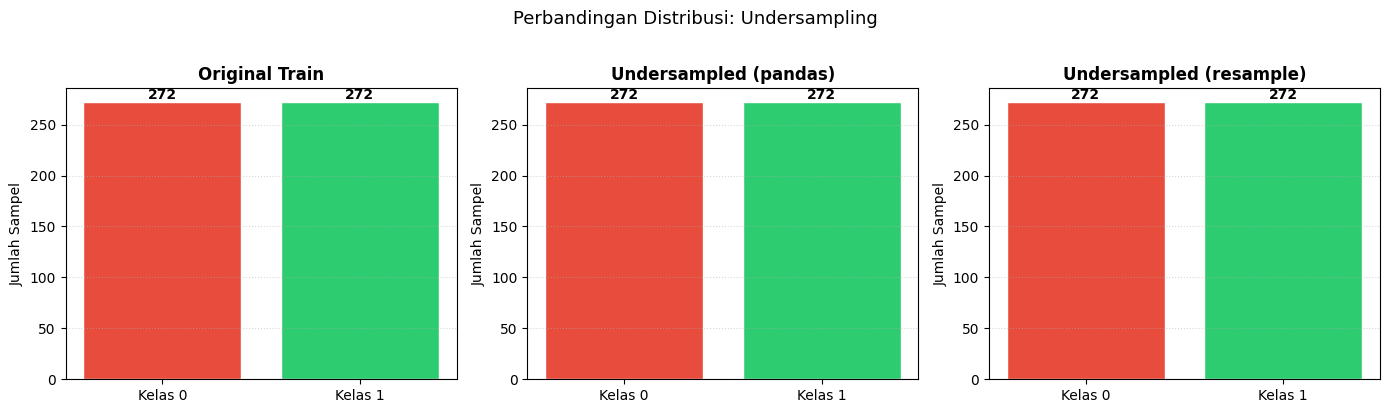

In [12]:
# Pisahkan berdasar kelas
df_train = pd.concat([X_train, y_train], axis=1)

df_majority = df_train[df_train[TARGET] == 0]   # Not Survived
df_minority = df_train[df_train[TARGET] == 1]   # Survived

print(f"Sebelum undersampling:")
print(f"  Mayoritas (0): {len(df_majority)} | Minoritas (1): {len(df_minority)}")

# === Cara 1: Menggunakan pandas .sample() ===
df_majority_down = df_majority.sample(n=len(df_minority), random_state=42)
df_undersampled = pd.concat([df_majority_down, df_minority])
df_undersampled = df_undersampled.sample(frac=1, random_state=42).reset_index(drop=True)  # shuffle

print(f"\nSetelah Random Undersampling (pandas):")
print(f"  Distribusi: {Counter(df_undersampled[TARGET])}")

X_under_pd = df_undersampled[FEATURES]
y_under_pd = df_undersampled[TARGET]
results['Undersampling (pandas)'] = evaluate_model(
    RandomForestClassifier(n_estimators=100, random_state=42),
    X_under_pd, X_test, y_under_pd, y_test,
    title='Random Undersampling (pandas)'
)

# === Cara 2: Menggunakan sklearn.utils.resample ===
df_majority_down2 = resample(
    df_majority,
    replace=False,           # tanpa pengembalian (True = dengan pengembalian)
    n_samples=len(df_minority),
    random_state=42
)
df_undersampled2 = pd.concat([df_majority_down2, df_minority])\
                    .sample(frac=1, random_state=42).reset_index(drop=True)

print(f"\nSetelah Random Undersampling (sklearn resample):")
print(f"  Distribusi: {Counter(df_undersampled2[TARGET])}")

# Visualisasi perbandingan distribusi
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
titles  = ['Original Train', 'Undersampled (pandas)', 'Undersampled (resample)']
dists   = [Counter(y_train), Counter(y_under_pd), Counter(df_undersampled2[TARGET])]
colors  = [['#e74c3c', '#2ecc71']] * 3

for ax, title, dist in zip(axes, titles, dists):
    vals = [dist[0], dist[1]]
    bars = ax.bar(['Kelas 0', 'Kelas 1'], vals, color=['#e74c3c', '#2ecc71'], edgecolor='white')
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                str(v), ha='center', va='bottom', fontweight='bold')
    ax.set_title(title, fontweight='bold')
    ax.set_ylabel('Jumlah Sampel')
    ax.grid(axis='y', linestyle=':', alpha=0.5)

plt.suptitle('Perbandingan Distribusi: Undersampling', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

### 6. Teknik 2: Random Oversampling (Upsampling)
**Oversampling** menambah jumlah sampel kelas minoritas dengan menduplikasi sampel yang ada secara acak (dengan pengembalian). Tidak kehilangan informasi seperti undersampling, tapi risiko **overfitting** pada kelas minoritas karena sampel yang benar-benar baru tidak dibuat — hanya duplikasi.

In [13]:
print(f"Sebelum oversampling:")
print(f"  Mayoritas (0): {len(df_majority)} | Minoritas (1): {len(df_minority)}")

# === Cara 1: Oversampling dengan pandas .sample(replace=True) ===
df_minority_up = df_minority.sample(n=len(df_majority), replace=True, random_state=42)
df_oversampled = pd.concat([df_majority, df_minority_up])\
                  .sample(frac=1, random_state=42).reset_index(drop=True)

print(f"\nSetelah Random Oversampling (pandas):")
print(f"  Distribusi: {Counter(df_oversampled[TARGET])}")

X_over_pd = df_oversampled[FEATURES]
y_over_pd = df_oversampled[TARGET]
results['Oversampling (pandas)'] = evaluate_model(
    RandomForestClassifier(n_estimators=100, random_state=42),
    X_over_pd, X_test, y_over_pd, y_test,
    title='Random Oversampling (pandas)'
)

# === Cara 2: Oversampling dengan sklearn resample ===
df_minority_up2 = resample(
    df_minority,
    replace=True,            # dengan pengembalian (duplikasi)
    n_samples=len(df_majority),
    random_state=42
)
df_oversampled2 = pd.concat([df_majority, df_minority_up2])\
                   .sample(frac=1, random_state=42).reset_index(drop=True)

print(f"\nSetelah Random Oversampling (sklearn resample):")
print(f"  Distribusi: {Counter(df_oversampled2[TARGET])}")

Sebelum oversampling:
  Mayoritas (0): 272 | Minoritas (1): 272

Setelah Random Oversampling (pandas):
  Distribusi: Counter({1: 272, 0: 272})

  Random Oversampling (pandas)
  Accuracy : 0.8015
  F1-Macro : 0.8012  ← metrik utama untuk imbalanced
  Precision: 0.8254 (kelas 1 = Survived)
  Recall   : 0.7647 (kelas 1 = Survived)
  ROC-AUC  : 0.8521

  Classification Report:
              precision    recall  f1-score   support

Not Survived       0.78      0.84      0.81        68
    Survived       0.83      0.76      0.79        68

    accuracy                           0.80       136
   macro avg       0.80      0.80      0.80       136
weighted avg       0.80      0.80      0.80       136


Setelah Random Oversampling (sklearn resample):
  Distribusi: Counter({1: 272, 0: 272})


### 7. Teknik 3: SMOTE (Synthetic Minority Oversampling Technique)
**SMOTE** adalah teknik oversampling canggih yang **membuat sampel sintetis baru** (bukan duplikasi) untuk kelas minoritas. Caranya: untuk setiap sampel minoritas, cari K-Nearest Neighbors, lalu interpolasi di antara titik-titik tersebut untuk membuat sampel baru yang realistis. SMOTE jauh lebih baik dari random oversampling karena mengurangi overfitting.

In [14]:
if IMBLEARN_AVAILABLE:
    # SMOTE standar
    smote = SMOTE(random_state=42, k_neighbors=5)
    X_smote, y_smote = smote.fit_resample(X_train, y_train)

    print(f"Distribusi sebelum SMOTE : {Counter(y_train)}")
    print(f"Distribusi setelah SMOTE : {Counter(y_smote)}")
    print(f"Sampel baru dibuat       : {len(y_smote) - len(y_train)}")

    results['SMOTE'] = evaluate_model(
        RandomForestClassifier(n_estimators=100, random_state=42),
        X_smote, X_test, y_smote, y_test,
        title='SMOTE'
    )

    # BorderlineSMOTE: fokus pada sampel di area perbatasan (lebih agresif)
    border_smote = BorderlineSMOTE(random_state=42, kind='borderline-1')
    X_bsmote, y_bsmote = border_smote.fit_resample(X_train, y_train)

    print(f"\nDistribusi setelah BorderlineSMOTE: {Counter(y_bsmote)}")
    results['BorderlineSMOTE'] = evaluate_model(
        RandomForestClassifier(n_estimators=100, random_state=42),
        X_bsmote, X_test, y_bsmote, y_test,
        title='BorderlineSMOTE'
    )

    # ADASYN: Adaptive Synthetic Sampling — lebih banyak sampel di area sulit
    adasyn = ADASYN(random_state=42)
    X_adasyn, y_adasyn = adasyn.fit_resample(X_train, y_train)

    print(f"Distribusi setelah ADASYN: {Counter(y_adasyn)}")
    results['ADASYN'] = evaluate_model(
        RandomForestClassifier(n_estimators=100, random_state=42),
        X_adasyn, X_test, y_adasyn, y_test,
        title='ADASYN'
    )
else:
    print("imbalanced-learn tidak tersedia. Lewati cell ini.")
    print("Install dengan: pip install imbalanced-learn")

imbalanced-learn tidak tersedia. Lewati cell ini.
Install dengan: pip install imbalanced-learn


### 8. Teknik 4: Undersampling Cerdas (Tomek Links & ENN)
Berbeda dengan random undersampling, teknik ini **membuang sampel mayoritas yang paling ambigu** (yang berada dekat dengan batas keputusan). **Tomek Links** menghapus pasangan sampel berbeda kelas yang saling menjadi tetangga terdekat. **Edited Nearest Neighbours (ENN)** membuang sampel mayoritas yang diklasifikasikan salah oleh KNN. Hasilnya: batas keputusan lebih bersih tanpa mengurangi terlalu banyak data.

In [15]:
if IMBLEARN_AVAILABLE:
    print(f"Data train awal: {Counter(y_train)}")

    # Tomek Links
    tomek = TomekLinks()
    X_tomek, y_tomek = tomek.fit_resample(X_train, y_train)
    print(f"\nSetelah Tomek Links: {Counter(y_tomek)}")
    print(f"  Sampel dihapus: {len(y_train) - len(y_tomek)}")

    results['TomekLinks'] = evaluate_model(
        RandomForestClassifier(n_estimators=100, random_state=42),
        X_tomek, X_test, y_tomek, y_test,
        title='Tomek Links Undersampling'
    )

    # Edited Nearest Neighbours
    enn = EditedNearestNeighbours()
    X_enn, y_enn = enn.fit_resample(X_train, y_train)
    print(f"\nSetelah ENN: {Counter(y_enn)}")
    print(f"  Sampel dihapus: {len(y_train) - len(y_enn)}")

    results['ENN'] = evaluate_model(
        RandomForestClassifier(n_estimators=100, random_state=42),
        X_enn, X_test, y_enn, y_test,
        title='Edited Nearest Neighbours'
    )
else:
    print("imbalanced-learn tidak tersedia.")

imbalanced-learn tidak tersedia.


### 9. Teknik 5: Kombinasi Over + Undersampling (SMOTE-Tomek & SMOTE-ENN)
Teknik **kombinasi** menggabungkan kelebihan keduanya: SMOTE membuat sampel sintetis minoritas, kemudian Tomek Links atau ENN membersihkan noise dari mayoritas di area perbatasan. Ini sering memberikan hasil terbaik karena dataset menjadi lebih seimbang **dan** lebih bersih.

In [16]:
if IMBLEARN_AVAILABLE:
    print(f"Data train awal: {Counter(y_train)}")

    # SMOTE + Tomek Links
    smote_tomek = SMOTETomek(random_state=42)
    X_smtomek, y_smtomek = smote_tomek.fit_resample(X_train, y_train)
    print(f"\nSetelah SMOTE-Tomek: {Counter(y_smtomek)}")

    results['SMOTE-Tomek'] = evaluate_model(
        RandomForestClassifier(n_estimators=100, random_state=42),
        X_smtomek, X_test, y_smtomek, y_test,
        title='SMOTE + Tomek Links (Kombinasi)'
    )

    # SMOTE + ENN
    smote_enn = SMOTEENN(random_state=42)
    X_smenn, y_smenn = smote_enn.fit_resample(X_train, y_train)
    print(f"\nSetelah SMOTE-ENN: {Counter(y_smenn)}")

    results['SMOTE-ENN'] = evaluate_model(
        RandomForestClassifier(n_estimators=100, random_state=42),
        X_smenn, X_test, y_smenn, y_test,
        title='SMOTE + ENN (Kombinasi)'
    )
else:
    print("imbalanced-learn tidak tersedia.")

imbalanced-learn tidak tersedia.


### 10. Teknik 6: Class Weight (Tanpa Resampling)
Teknik ini **tidak mengubah jumlah sampel** sama sekali — melainkan memberikan **bobot lebih besar** ke kelas minoritas saat menghitung loss. Model akan "dikenakan penalti lebih berat" jika salah mengklasifikasikan kelas minoritas. Didukung langsung oleh `class_weight='balanced'` di hampir semua estimator sklearn dan juga di PyTorch melalui `nn.CrossEntropyLoss(weight=...)`. Ini adalah pendekatan **paling aman** dan sering direkomendasikan sebagai langkah pertama.

In [17]:
from sklearn.utils.class_weight import compute_class_weight

# Hitung class weight manual
classes = np.array([0, 1])
cw = compute_class_weight('balanced', classes=classes, y=y_train)
class_weight_dict = dict(zip(classes, cw))
print(f"Class weights: {class_weight_dict}")
print(f"  Kelas 0 (mayoritas) mendapat bobot: {cw[0]:.4f}")
print(f"  Kelas 1 (minoritas) mendapat bobot: {cw[1]:.4f} ← lebih berat")

# === Sklearn: class_weight='balanced' ===
clf_weighted = RandomForestClassifier(
    n_estimators=100,
    class_weight='balanced',    # otomatis hitung bobot
    random_state=42
)
results['ClassWeight (balanced)'] = evaluate_model(
    clf_weighted, X_train, X_test, y_train, y_test,
    title='Class Weight (balanced)'
)

# === Logistic Regression dengan class_weight ===
clf_lr_weighted = LogisticRegression(
    class_weight='balanced',
    max_iter=1000,
    random_state=42
)
results['LR ClassWeight'] = evaluate_model(
    clf_lr_weighted, X_train, X_test, y_train, y_test,
    title='Logistic Regression + Class Weight'
)

# === PyTorch equivalen (cara menghitung tensor weight untuk CrossEntropyLoss) ===
import torch
print("\n=== PyTorch: Class Weight untuk CrossEntropyLoss ===")
class_weights_tensor = torch.tensor(cw, dtype=torch.float32)
print(f"Tensor weight: {class_weights_tensor}")
print("Cara pakai:")
print("  criterion = nn.CrossEntropyLoss(weight=class_weights_tensor.to(device))")

Class weights: {np.int64(0): np.float64(1.0), np.int64(1): np.float64(1.0)}
  Kelas 0 (mayoritas) mendapat bobot: 1.0000
  Kelas 1 (minoritas) mendapat bobot: 1.0000 ← lebih berat

  Class Weight (balanced)
  Accuracy : 0.8015
  F1-Macro : 0.8015  ← metrik utama untuk imbalanced
  Precision: 0.7971 (kelas 1 = Survived)
  Recall   : 0.8088 (kelas 1 = Survived)
  ROC-AUC  : 0.8499

  Classification Report:
              precision    recall  f1-score   support

Not Survived       0.81      0.79      0.80        68
    Survived       0.80      0.81      0.80        68

    accuracy                           0.80       136
   macro avg       0.80      0.80      0.80       136
weighted avg       0.80      0.80      0.80       136


  Logistic Regression + Class Weight
  Accuracy : 0.7647
  F1-Macro : 0.7647  ← metrik utama untuk imbalanced
  Precision: 0.7727 (kelas 1 = Survived)
  Recall   : 0.7500 (kelas 1 = Survived)
  ROC-AUC  : 0.8553

  Classification Report:
              precision   

### 11. Teknik 7: Threshold Tuning (Optimasi Ambang Batas Prediksi)
Secara default, model mengklasifikasikan sampel ke kelas 1 jika probabilitasnya > 0.5. Pada imbalanced dataset, **menurunkan threshold ini** (misal ke 0.3–0.4) dapat meningkatkan **recall** kelas minoritas dengan sedikit mengorbankan precision — trade-off yang sering diinginkan (misal lebih baik deteksi fraud berlebihan daripada melewatkan kasus fraud).

=== Efek Threshold terhadap Precision, Recall, F1 ===
 Threshold  Precision   Recall   F1-Score   Accuracy
-------------------------------------------------------
      0.20     0.6061   0.8824     0.7186     0.6544
      0.25     0.6250   0.8824     0.7317     0.6765
      0.30     0.6556   0.8676     0.7468     0.7059
      0.35     0.6786   0.8382     0.7500     0.7206
      0.40     0.7215   0.8382     0.7755     0.7574
      0.45     0.7368   0.8235     0.7778     0.7647
      0.50     0.7971   0.8088     0.8029     0.8015 ← default
      0.55     0.8060   0.7941     0.8000     0.8015
      0.60     0.8182   0.7941     0.8060     0.8088
      0.65     0.8772   0.7353     0.8000     0.8162
      0.70     0.8704   0.6912     0.7705     0.7941
      0.75     0.8958   0.6324     0.7414     0.7794
      0.80     0.9070   0.5735     0.7027     0.7574

Threshold optimal (F1 maks): 0.60
  F1=0.8060 | Prec=0.8182 | Rec=0.7941


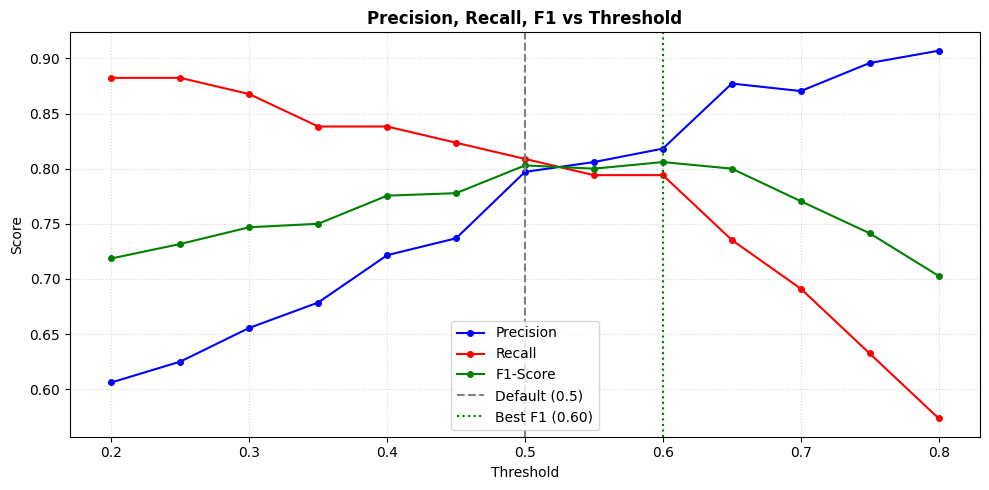

In [18]:
from sklearn.metrics import precision_recall_curve

# Latih model baseline, ambil probabilitas
clf_thresh = RandomForestClassifier(n_estimators=100, random_state=42)
clf_thresh.fit(X_train, y_train)
y_prob_test = clf_thresh.predict_proba(X_test)[:, 1]

print("=== Efek Threshold terhadap Precision, Recall, F1 ===")
print(f"{'Threshold':>10} {'Precision':>10} {'Recall':>8} {'F1-Score':>10} {'Accuracy':>10}")
print("-" * 55)

threshold_results = []
for thresh in np.arange(0.2, 0.81, 0.05):
    y_pred_t = (y_prob_test >= thresh).astype(int)
    prec = precision_score(y_test, y_pred_t, zero_division=0)
    rec  = recall_score(y_test, y_pred_t, zero_division=0)
    f1   = f1_score(y_test, y_pred_t, zero_division=0)
    acc  = accuracy_score(y_test, y_pred_t)
    threshold_results.append({'threshold': thresh, 'precision': prec,
                               'recall': rec, 'f1': f1, 'accuracy': acc})
    marker = " ← default" if abs(thresh - 0.5) < 0.01 else ""
    print(f"  {thresh:>8.2f} {prec:>10.4f} {rec:>8.4f} {f1:>10.4f} {acc:>10.4f}{marker}")

# Threshold dengan F1 terbaik
df_thresh = pd.DataFrame(threshold_results)
best_thresh = df_thresh.loc[df_thresh['f1'].idxmax()]
print(f"\nThreshold optimal (F1 maks): {best_thresh['threshold']:.2f}")
print(f"  F1={best_thresh['f1']:.4f} | Prec={best_thresh['precision']:.4f} | Rec={best_thresh['recall']:.4f}")

# Visualisasi
plt.figure(figsize=(10, 5))
plt.plot(df_thresh['threshold'], df_thresh['precision'], 'b-o', markersize=4, label='Precision')
plt.plot(df_thresh['threshold'], df_thresh['recall'],    'r-o', markersize=4, label='Recall')
plt.plot(df_thresh['threshold'], df_thresh['f1'],        'g-o', markersize=4, label='F1-Score')
plt.axvline(0.5, color='gray', linestyle='--', label='Default (0.5)')
plt.axvline(best_thresh['threshold'], color='green', linestyle=':', label=f"Best F1 ({best_thresh['threshold']:.2f})")
plt.xlabel('Threshold')
plt.ylabel('Score')
plt.title('Precision, Recall, F1 vs Threshold', fontweight='bold')
plt.legend()
plt.grid(linestyle=':', alpha=0.5)
plt.tight_layout()
plt.show()

### 12. Teknik 8: Stratified K-Fold Cross Validation
Pada imbalanced dataset, evaluasi model yang benar **wajib** menggunakan **Stratified K-Fold** — yang memastikan setiap fold memiliki proporsi kelas yang sama dengan dataset keseluruhan. K-Fold biasa bisa menghasilkan fold yang hampir seluruhnya berisi kelas mayoritas, membuat evaluasi tidak valid.

=== Stratified 5-Fold Cross Validation ===

  [RF Baseline]
    accuracy            : 0.7809 ± 0.0194
    f1_macro            : 0.7804 ± 0.0194
    precision_macro     : 0.7831 ± 0.0198
    recall_macro        : 0.7809 ± 0.0194
    roc_auc             : 0.8491 ± 0.0240

  [RF Class Weight]
    accuracy            : 0.7809 ± 0.0194
    f1_macro            : 0.7804 ± 0.0194
    precision_macro     : 0.7831 ± 0.0198
    recall_macro        : 0.7809 ± 0.0194
    roc_auc             : 0.8491 ± 0.0240

  [LR Class Weight]
    accuracy            : 0.7706 ± 0.0404
    f1_macro            : 0.7703 ± 0.0404
    precision_macro     : 0.7718 ± 0.0406
    recall_macro        : 0.7706 ± 0.0404
    roc_auc             : 0.8442 ± 0.0275


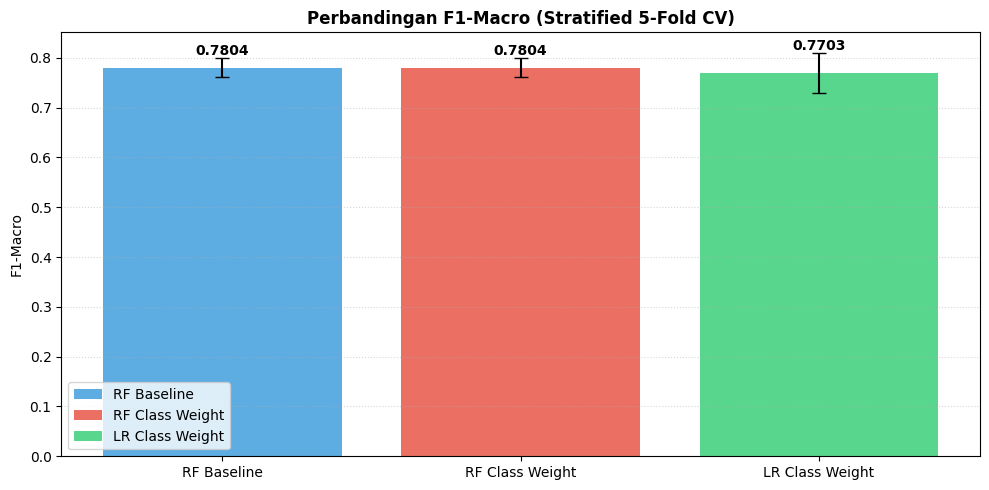

In [19]:
from sklearn.model_selection import StratifiedKFold, cross_validate

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Evaluasi beberapa model dengan stratified CV
models_to_cv = {
    'RF Baseline'       : RandomForestClassifier(n_estimators=100, random_state=42),
    'RF Class Weight'   : RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42),
    'LR Class Weight'   : LogisticRegression(class_weight='balanced', max_iter=1000),
}

scoring_metrics = ['accuracy', 'f1_macro', 'precision_macro', 'recall_macro', 'roc_auc']

print("=== Stratified 5-Fold Cross Validation ===")
cv_results_all = {}

for name, model in models_to_cv.items():
    cv_res = cross_validate(
        model, X, y,
        cv=skf,
        scoring=scoring_metrics,
        return_train_score=False
    )
    cv_results_all[name] = cv_res
    print(f"\n  [{name}]")
    for metric in scoring_metrics:
        scores = cv_res[f'test_{metric}']
        print(f"    {metric:<20}: {scores.mean():.4f} ± {scores.std():.4f}")

# Visualisasi perbandingan F1-Macro antar model
fig, ax = plt.subplots(figsize=(10, 5))
colors = ['#3498db', '#e74c3c', '#2ecc71']

for i, (name, cv_res) in enumerate(cv_results_all.items()):
    scores = cv_res['test_f1_macro']
    ax.bar(i, scores.mean(), yerr=scores.std(), capsize=5,
           color=colors[i], alpha=0.8, label=name)
    ax.text(i, scores.mean() + scores.std() + 0.005,
            f'{scores.mean():.4f}', ha='center', fontweight='bold')

ax.set_xticks(range(len(cv_results_all)))
ax.set_xticklabels(cv_results_all.keys())
ax.set_ylabel('F1-Macro')
ax.set_title('Perbandingan F1-Macro (Stratified 5-Fold CV)', fontweight='bold')
ax.grid(axis='y', linestyle=':', alpha=0.5)
ax.legend()
plt.tight_layout()
plt.show()

### 13. Perbandingan Semua Teknik — Dashboard Hasil
Visualisasi perbandingan komprehensif semua teknik yang telah diuji. Metrik utama yang diperhatikan untuk imbalanced dataset adalah **F1-Macro** dan **ROC-AUC** — bukan hanya akurasi, karena akurasi tinggi bisa dicapai dengan hanya memprediksi kelas mayoritas saja.

=== Ringkasan Semua Teknik (diurutkan F1-Macro) ===


,Accuracy,F1-Macro,Precision,Recall,ROC-AUC
Teknik,,,,,
Baseline,0.8015,0.8015,0.7971,0.8088,0.8499
Undersampling (pandas),0.8015,0.8015,0.7971,0.8088,0.8482
ClassWeight (balanced),0.8015,0.8015,0.7971,0.8088,0.8499
Oversampling (pandas),0.8015,0.8012,0.8254,0.7647,0.8521
LR ClassWeight,0.7647,0.7647,0.7727,0.7500,0.8553


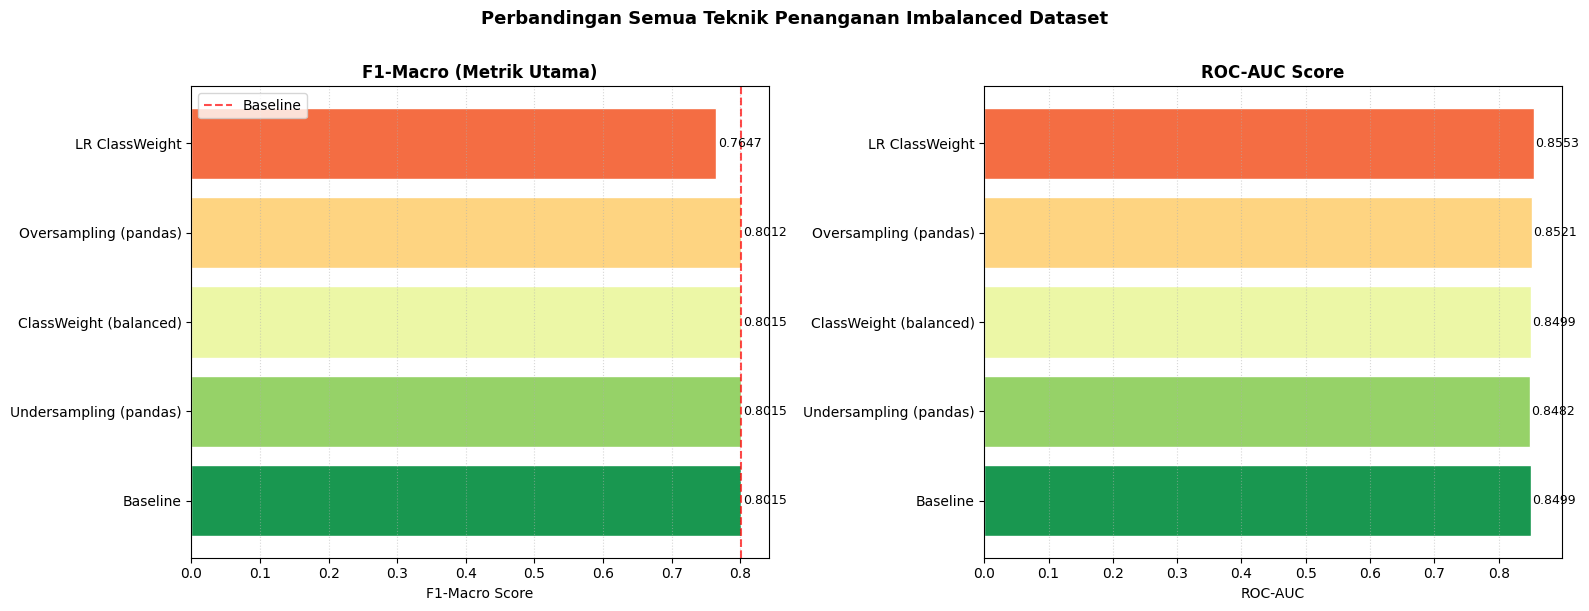

In [20]:
# Buat DataFrame dari semua hasil
summary_data = []
for name, res in results.items():
    summary_data.append({
        'Teknik'   : name,
        'Accuracy' : res['accuracy'],
        'F1-Macro' : res['f1_macro'],
        'Precision': res['precision'],
        'Recall'   : res['recall'],
        'ROC-AUC'  : res['roc_auc'],
    })

df_summary = pd.DataFrame(summary_data).set_index('Teknik')
df_summary_sorted = df_summary.sort_values('F1-Macro', ascending=False)

print("=== Ringkasan Semua Teknik (diurutkan F1-Macro) ===")
display(df_summary_sorted.style
    .background_gradient(cmap='RdYlGn', subset=['F1-Macro', 'Recall', 'ROC-AUC'])
    .format('{:.4f}')
    .set_caption('Perbandingan Teknik Penanganan Imbalanced Dataset')
)

# Visualisasi: grouped bar chart
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
metrics_to_plot = ['Accuracy', 'F1-Macro', 'Recall', 'ROC-AUC']

# Bar chart F1-Macro
ax = axes[0]
colors_bar = plt.cm.RdYlGn(np.linspace(0.2, 0.9, len(df_summary_sorted)))
bars = ax.barh(df_summary_sorted.index, df_summary_sorted['F1-Macro'],
               color=colors_bar[::-1], edgecolor='white')
for bar, val in zip(bars, df_summary_sorted['F1-Macro']):
    ax.text(val + 0.003, bar.get_y() + bar.get_height()/2,
            f'{val:.4f}', va='center', fontsize=9)
ax.set_title('F1-Macro (Metrik Utama)', fontweight='bold', fontsize=12)
ax.set_xlabel('F1-Macro Score')
ax.axvline(df_summary.loc['Baseline', 'F1-Macro'], color='red',
           linestyle='--', alpha=0.7, label='Baseline')
ax.legend()
ax.grid(axis='x', linestyle=':', alpha=0.5)

# Bar chart ROC-AUC
ax = axes[1]
df_roc = df_summary_sorted.dropna(subset=['ROC-AUC'])
colors_roc = plt.cm.RdYlGn(np.linspace(0.2, 0.9, len(df_roc)))
bars = ax.barh(df_roc.index, df_roc['ROC-AUC'],
               color=colors_roc[::-1], edgecolor='white')
for bar, val in zip(bars, df_roc['ROC-AUC']):
    ax.text(val + 0.002, bar.get_y() + bar.get_height()/2,
            f'{val:.4f}', va='center', fontsize=9)
ax.set_title('ROC-AUC Score', fontweight='bold', fontsize=12)
ax.set_xlabel('ROC-AUC')
ax.grid(axis='x', linestyle=':', alpha=0.5)

plt.suptitle('Perbandingan Semua Teknik Penanganan Imbalanced Dataset',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

### 14. Confusion Matrix Visual Semua Teknik
Confusion matrix memberikan gambaran visual paling intuitif tentang perbedaan antar teknik: berapa banyak kelas minoritas yang berhasil terdeteksi (True Positive / Recall) versus yang terlewat (False Negative).

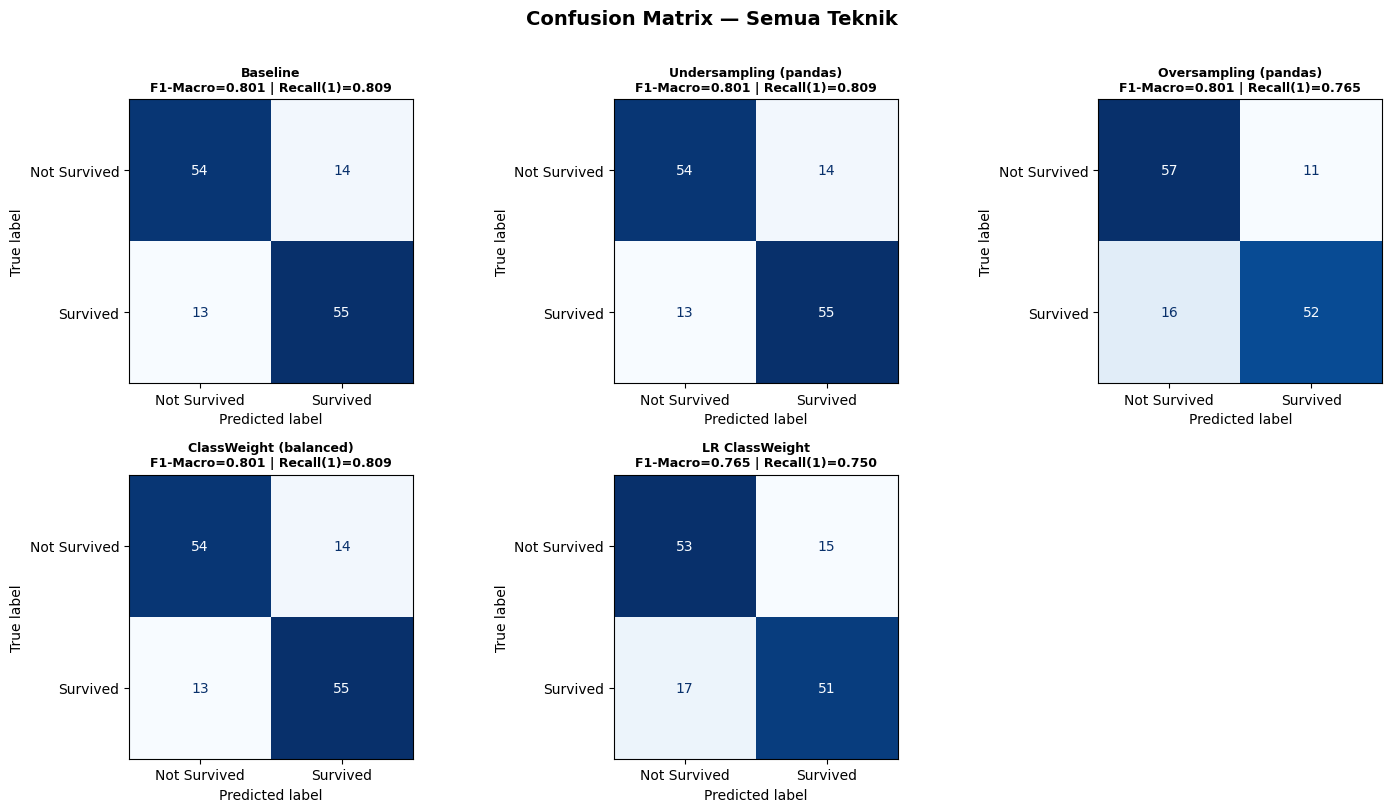

In [21]:
n_results = len(results)
ncols = 3
nrows = (n_results + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 5, nrows * 4))
axes_flat = axes.flatten()

for i, (name, res) in enumerate(results.items()):
    cm = confusion_matrix(y_test, res['y_pred'])
    disp = ConfusionMatrixDisplay(cm, display_labels=['Not Survived', 'Survived'])
    disp.plot(ax=axes_flat[i], colorbar=False, cmap='Blues')
    f1  = res['f1_macro']
    rec = res['recall']
    axes_flat[i].set_title(f'{name}\nF1-Macro={f1:.3f} | Recall(1)={rec:.3f}',
                            fontsize=9, fontweight='bold')

# Sembunyikan subplot yang kosong
for j in range(i + 1, len(axes_flat)):
    axes_flat[j].set_visible(False)

plt.suptitle('Confusion Matrix — Semua Teknik', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

### 15. Panduan Pemilihan Teknik & Ringkasan
Panduan praktis untuk memilih teknik yang tepat berdasarkan kondisi dataset dan kebutuhan pipeline.

In [22]:
guide = """
╔══════════════════════════════════════════════════════════════════════════════╗
║          PANDUAN PEMILIHAN TEKNIK PENANGANAN IMBALANCED DATASET             ║
╠══════════════════════╦═════════════════════════════════════════════════════╣
║ Kondisi              ║ Rekomendasi Teknik                                  ║
╠══════════════════════╬═════════════════════════════════════════════════════╣
║ Dataset kecil (<5K)  ║ SMOTE / ADASYN — buat sampel sintetis baru         ║
║ Dataset sedang       ║ SMOTE + Tomek atau SMOTE + ENN (kombinasi)          ║
║ Dataset besar (>1M)  ║ Class Weight — tidak perlu resampling, lebih cepat  ║
║ IR < 3               ║ Class Weight saja cukup                             ║
║ IR 3-10              ║ SMOTE atau Oversampling random + Class Weight        ║
║ IR > 10 (ekstrem)    ║ SMOTE-ENN / ADASYN + threshold tuning               ║
║ Perlu interpretasi   ║ Hindari SMOTE pada fitur kategorikal — pakai Weight  ║
║ Pipeline PyTorch     ║ class_weight di CrossEntropyLoss + threshold tuning  ║
╠══════════════════════╩═════════════════════════════════════════════════════╣
║ METRIK EVALUASI YANG BENAR UNTUK IMBALANCED DATASET:                       ║
║  ✓ F1-Macro / F1-Weighted  (bukan hanya Accuracy!)                         ║
║  ✓ ROC-AUC                 (area under curve)                               ║
║  ✓ Precision-Recall AUC    (lebih informatif dari ROC-AUC saat IR tinggi)  ║
║  ✓ Recall kelas minoritas  (seberapa banyak kasus penting yang terdeteksi) ║
║  ✗ Accuracy saja           (MENYESATKAN pada imbalanced dataset!)           ║
╠══════════════════════════════════════════════════════════════════════════════╣
║ URUTAN LANGKAH YANG DISARANKAN:                                             ║
║  1. Ukur IR dan visualisasi distribusi kelas                                ║
║  2. Train baseline → lihat recall kelas minoritas                           ║
║  3. Coba class_weight='balanced' terlebih dahulu (paling aman)              ║
║  4. Jika masih kurang → coba SMOTE atau kombinasi SMOTE-Tomek               ║
║  5. Tune threshold berdasar precision-recall trade-off                      ║
║  6. Selalu evaluasi dengan Stratified K-Fold, bukan single split            ║
╚══════════════════════════════════════════════════════════════════════════════╝
"""
print(guide)

# Tampilkan tabel ringkasan final
print("=== Ringkasan Teknik yang Diimplementasikan ===")
summary_table = {
    'Teknik'            : ['Random Undersampling', 'Random Oversampling', 'SMOTE',
                            'BorderlineSMOTE', 'ADASYN', 'Tomek Links', 'ENN',
                            'SMOTE-Tomek', 'SMOTE-ENN', 'Class Weight', 'Threshold Tuning'],
    'Tipe'              : ['Under', 'Over', 'Over', 'Over', 'Over', 'Under', 'Under',
                            'Kombinasi', 'Kombinasi', 'Bobot', 'Post-processing'],
    'Ubah Data?'        : ['Ya', 'Ya', 'Ya (sintetis)', 'Ya (sintetis)', 'Ya (sintetis)',
                            'Ya', 'Ya', 'Ya (keduanya)', 'Ya (keduanya)', 'Tidak', 'Tidak'],
    'Library'           : ['pandas/sklearn', 'pandas/sklearn', 'imblearn', 'imblearn', 'imblearn',
                            'imblearn', 'imblearn', 'imblearn', 'imblearn', 'sklearn', 'sklearn'],
}
display(pd.DataFrame(summary_table))


╔══════════════════════════════════════════════════════════════════════════════╗
║          PANDUAN PEMILIHAN TEKNIK PENANGANAN IMBALANCED DATASET             ║
╠══════════════════════╦═════════════════════════════════════════════════════╣
║ Kondisi              ║ Rekomendasi Teknik                                  ║
╠══════════════════════╬═════════════════════════════════════════════════════╣
║ Dataset kecil (<5K)  ║ SMOTE / ADASYN — buat sampel sintetis baru         ║
║ Dataset sedang       ║ SMOTE + Tomek atau SMOTE + ENN (kombinasi)          ║
║ Dataset besar (>1M)  ║ Class Weight — tidak perlu resampling, lebih cepat  ║
║ IR < 3               ║ Class Weight saja cukup                             ║
║ IR 3-10              ║ SMOTE atau Oversampling random + Class Weight        ║
║ IR > 10 (ekstrem)    ║ SMOTE-ENN / ADASYN + threshold tuning               ║
║ Perlu interpretasi   ║ Hindari SMOTE pada fitur kategorikal — pakai Weight  ║
║ Pipeline PyTorch     ║ class_weight di CrossE

,Teknik,Tipe,Ubah Data?,Library
0,Random Undersampling,Under,Ya,pandas/sklearn
1,Random Oversampling,Over,Ya,pandas/sklearn
2,SMOTE,Over,Ya (sintetis),imblearn
3,BorderlineSMOTE,Over,Ya (sintetis),imblearn
4,ADASYN,Over,Ya (sintetis),imblearn
5,Tomek Links,Under,Ya,imblearn
6,ENN,Under,Ya,imblearn
7,SMOTE-Tomek,Kombinasi,Ya (keduanya),imblearn
8,SMOTE-ENN,Kombinasi,Ya (keduanya),imblearn
9,Class Weight,Bobot,Tidak,sklearn
